# Waste Complaint Classification Using Word Embeddings

This notebook implements a waste complaint classification model using word embeddings for feature extraction. It includes sections for loading and preprocessing the dataset, creating word embeddings, training the classification model, evaluating its performance, and saving the trained model.

## Workflow

1. Load and validate the labeled CSV dataset.
2. Normalize complaint text by lowercasing and removing unnecessary punctuation and whitespace.
3. Create word embeddings using a pre-trained model.
4. Split the data into stratified training and testing sets.
5. Train a classification model using the embeddings.
6. Measure accuracy, precision, recall, F1-score, and the confusion matrix.
7. Save the trained model for future use.

In [1]:
# Install all notebook dependencies in the active Jupyter kernel.
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from gensim.models import Word2Vec
import gensim.downloader as api
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from transformers import AutoModel, AutoTokenizer

RANDOM_STATE = 42
DATA_PATH = Path("waste_complaints_nlp_dataset.csv")
MODEL_DIR = Path("model")
MODEL_PATH = MODEL_DIR / "waste_complaint_embeddings_classifier.joblib"
EXPECTED_LABELS = {
    "missed_pickup",
    "delayed_pickup",
    "illegal_dumping",
    "full_bin",
    "recycling_question",
}


## Load and Validate the Dataset

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {"id", "text", "label"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = df[["id", "text", "label"]].copy()
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str).str.strip()
df = df[df["text"].str.strip().ne("") & df["label"].ne("")].copy()

unexpected_labels = set(df["label"]) - EXPECTED_LABELS
if unexpected_labels:
    raise ValueError(f"Unexpected labels found: {sorted(unexpected_labels)}")

print(f"Rows available for training: {len(df):,}")
print(f"Unique labels: {sorted(df['label'].unique())}")
display(df.head())
display(df["label"].value_counts().sort_index())

Rows available for training: 10
Unique labels: ['delayed_pickup', 'full_bin', 'illegal_dumping', 'missed_pickup', 'recycling_question']


,id,text,label
0,1,Our rubbish has not been collected this week.,missed_pickup
1,2,There is a huge pile of rubbish dumped next to...,illegal_dumping
2,3,Where can I recycle plastic bottles?,recycling_question
3,4,The communal bin is completely full.,full_bin
4,5,The collectors came two days late.,delayed_pickup


label
delayed_pickup        2
full_bin              2
illegal_dumping       2
missed_pickup         2
recycling_question    2
Name: count, dtype: int64

In [6]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_text"] = df["text"].map(clean_text)
df = df[df["clean_text"].ne("")].copy()

display(df[["text", "clean_text"]].head())


,text,clean_text
0,Our rubbish has not been collected this week.,our rubbish has not been collected this week
1,There is a huge pile of rubbish dumped next to...,there is a huge pile of rubbish dumped next to...
2,Where can I recycle plastic bottles?,where can i recycle plastic bottles
3,The communal bin is completely full.,the communal bin is completely full
4,The collectors came two days late.,the collectors came two days late


## Text Preprocessing

The same cleaning function is used during training and inference. It lowercases text, removes URLs and punctuation, and collapses repeated whitespace.

In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_text"] = df["text"].map(clean_text)
df = df[df["clean_text"].ne("")].copy()

display(df[["text", "clean_text"]].head())

,text,clean_text
0,Our rubbish has not been collected this week.,our rubbish has not been collected this week
1,There is a huge pile of rubbish dumped next to...,there is a huge pile of rubbish dumped next to...
2,Where can I recycle plastic bottles?,where can i recycle plastic bottles
3,The communal bin is completely full.,the communal bin is completely full
4,The collectors came two days late.,the collectors came two days late


## Create Word Embeddings

In [7]:
# Word2Vec embeddings trained on the complaint corpus.
tokenized_texts = [text.split() for text in df["clean_text"]]
word2vec_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=RANDOM_STATE,
)
word2vec_vectors = word2vec_model.wv


def get_word2vec_embedding(text: str) -> np.ndarray:
    embeddings = [word2vec_vectors[word] for word in text.split() if word in word2vec_vectors]
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(word2vec_vectors.vector_size)


df["word2vec_embedding"] = df["clean_text"].map(get_word2vec_embedding)
print(f"Word2Vec embedding size: {word2vec_vectors.vector_size}")


Word2Vec embedding size: 100


In [8]:
# Pre-trained GloVe embeddings downloaded through Gensim.
glove_vectors = api.load("glove-wiki-gigaword-100")


def get_glove_embedding(text: str) -> np.ndarray:
    embeddings = [glove_vectors[word] for word in text.split() if word in glove_vectors]
    return np.mean(embeddings, axis=0) if embeddings else np.zeros(glove_vectors.vector_size)


df["glove_embedding"] = df["clean_text"].map(get_glove_embedding)
print(f"GloVe embedding size: {glove_vectors.vector_size}")


GloVe embedding size: 100


In [9]:
# DistilBERT sentence embeddings using mean pooling over non-padding tokens.
BERT_MODEL_NAME = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.eval()


def get_bert_embeddings(texts: list[str], batch_size: int = 16) -> np.ndarray:
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        tokens = bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )
        with torch.no_grad():
            hidden_states = bert_model(**tokens).last_hidden_state
        mask = tokens["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        all_embeddings.append(pooled.cpu().numpy())
    return np.vstack(all_embeddings)


df["bert_embedding"] = list(get_bert_embeddings(df["clean_text"].tolist()))
print(f"BERT embedding size: {df['bert_embedding'].iloc[0].shape[0]}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embedding size: 768


In [12]:
embedding_columns = {
    "Word2Vec": "word2vec_embedding",
    "GloVe": "glove_embedding",
    "BERT": "bert_embedding",
}

indices = np.arange(len(df))
number_of_classes = df["label"].nunique()
test_size = max(0.20, number_of_classes / len(df))
train_indices, test_indices = train_test_split(
    indices,
    test_size=test_size,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)
y = df["label"].to_numpy()
trained_models = {}
metrics = []

for embedding_name, column in embedding_columns.items():
    X = np.vstack(df[column].to_numpy())
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    model.fit(X[train_indices], y[train_indices])
    predictions = model.predict(X[test_indices])
    trained_models[embedding_name] = model
    metrics.append({
        "embedding": embedding_name,
        "accuracy": accuracy_score(y[test_indices], predictions),
        "precision_macro": precision_score(y[test_indices], predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(y[test_indices], predictions, average="macro", zero_division=0),
        "f1_macro": f1_score(y[test_indices], predictions, average="macro", zero_division=0),
    })

results_df = pd.DataFrame(metrics)
print(f"Training examples: {len(train_indices):,}")
print(f"Testing examples: {len(test_indices):,}")
display(results_df)


Training examples: 5
Testing examples: 5


,embedding,accuracy,precision_macro,recall_macro,f1_macro
0,Word2Vec,0.6,0.466667,0.6,0.500000
1,GloVe,0.8,0.700000,0.8,0.733333
2,BERT,0.8,0.700000,0.8,0.733333


## Train/Test Split and Model Training

## Evaluate the Classifier

,embedding,accuracy,precision_macro,recall_macro,f1_macro
0,GloVe,0.800,0.700,0.800,0.733
1,BERT,0.800,0.700,0.800,0.733
2,Word2Vec,0.600,0.467,0.600,0.500


Best embedding: GloVe
                    precision    recall  f1-score   support

    delayed_pickup       0.00      0.00      0.00         1
          full_bin       1.00      1.00      1.00         1
   illegal_dumping       1.00      1.00      1.00         1
     missed_pickup       0.50      1.00      0.67         1
recycling_question       1.00      1.00      1.00         1

          accuracy                           0.80         5
         macro avg       0.70      0.80      0.73         5
      weighted avg       0.70      0.80      0.73         5



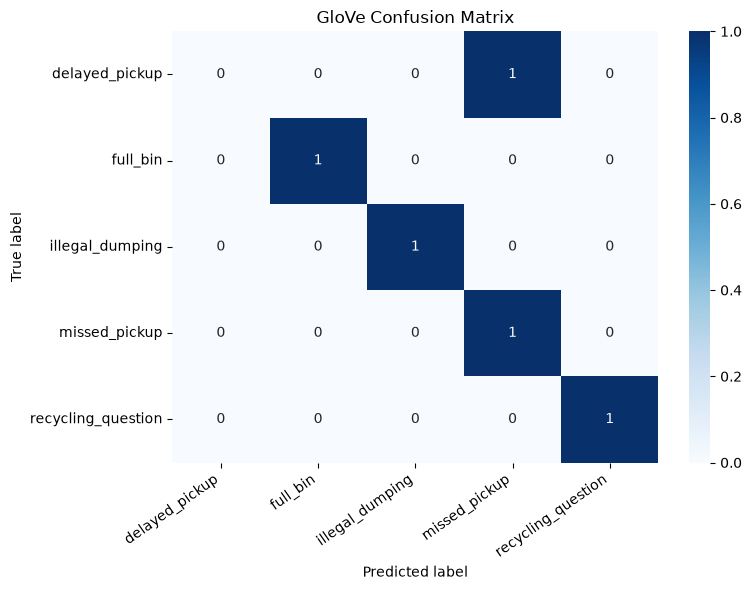

In [13]:
# Compare all embeddings and select the best model by macro F1, then accuracy.
comparison = results_df.sort_values(
    ["f1_macro", "accuracy"],
    ascending=False,
).reset_index(drop=True)
display(comparison.style.format({
    "accuracy": "{:.3f}",
    "precision_macro": "{:.3f}",
    "recall_macro": "{:.3f}",
    "f1_macro": "{:.3f}",
}))

best_embedding_name = comparison.loc[0, "embedding"]
best_model = trained_models[best_embedding_name]
best_embedding_column = embedding_columns[best_embedding_name]

embedding_getters = {
    "Word2Vec": get_word2vec_embedding,
    "GloVe": get_glove_embedding,
}
if best_embedding_name == "BERT":
    best_embedding_function = lambda text: get_bert_embeddings([text])[0]
else:
    best_embedding_function = embedding_getters[best_embedding_name]

best_test_embeddings = np.vstack(df.loc[test_indices, best_embedding_column].to_numpy())
best_predictions = best_model.predict(best_test_embeddings)
print(f"Best embedding: {best_embedding_name}")
print(classification_report(y[test_indices], best_predictions, zero_division=0))

confusion = confusion_matrix(
    y[test_indices],
    best_predictions,
    labels=sorted(EXPECTED_LABELS),
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(EXPECTED_LABELS),
    yticklabels=sorted(EXPECTED_LABELS),
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"{best_embedding_name} Confusion Matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Save the Trained Model

The saved object includes the Logistic Regression classifier, so new embeddings can be passed directly to `model.predict`.

In [14]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "model": best_model,
        "embedding_name": best_embedding_name,
        "embedding_column": best_embedding_column,
    },
    MODEL_PATH,
)
print(f"Saved best {best_embedding_name} model to: {MODEL_PATH.resolve()}")


Saved best GloVe model to: C:\Users\Hp\Desktop\tekher\Isuku-Models\waste-complaint-embeddings\model\waste_complaint_embeddings_classifier.joblib


## Try the Classifier

In [15]:
sample_complaints = [
    "Our rubbish has not been collected this week.",
    "There is a huge pile of rubbish dumped next to the road.",
    "Where can I recycle plastic bottles?",
    "The communal bin is completely full.",
    "The collectors came two days late.",
]

if best_embedding_name == "BERT":
    sample_embeddings = get_bert_embeddings([clean_text(text) for text in sample_complaints])
else:
    sample_embeddings = np.vstack([
        best_embedding_function(clean_text(text))
        for text in sample_complaints
    ])
sample_predictions = best_model.predict(sample_embeddings)
sample_results = pd.DataFrame({
    "complaint": sample_complaints,
    "predicted_category": sample_predictions,
})
display(sample_results)


,complaint,predicted_category
0,Our rubbish has not been collected this week.,missed_pickup
1,There is a huge pile of rubbish dumped next to...,illegal_dumping
2,Where can I recycle plastic bottles?,recycling_question
3,The communal bin is completely full.,full_bin
4,The collectors came two days late.,missed_pickup
